# Developmental Trajectory: Top 8 Densest Subjects (Month-to-Month RDM Correlation)

Instead of a median age split, this notebook analyzes the **age trajectory** of the **top 8 densest subjects** (by total category count from the trajectory file). For each subject we:

1. Build one RDM per **age month** (e.g. RDM at 6 months, 7 months, …) using only that month's embeddings.
2. **Consecutive-month correlations**: RDM_6 vs RDM_7, RDM_7 vs RDM_8, … (x = age transition, y = correlation).
3. **Youngest vs each later month**: For each subject, correlate the **youngest** month's RDM with **each** later month (e.g. if youngest is 6: 6 vs 7, 6 vs 8, 6 vs 9, …). x = later age, y = correlation with youngest month.
4. **All-categories analysis**: For each subject we take the **intersection** of categories available across all age months (the maximum set that overlaps at every age). We then use this **fixed set of objects** for every correlation for that subject across age, so comparisons are on the same categories at all time points. Dot size in all-categories plots is fixed (no longer encoding overlap). We also run the same analyses restricted to the **top 50 categories** from the long-tailed distribution (first 50 by proportion detected in `long_tailed_163cats/category_counts_163.csv`); top-50 analyses already use a fixed set.

**Density** is defined as in notebook 10: `n_categories_younger + n_categories_older` from `trajectory_correlations.csv` (developmental_trajectory_rdms).

## Setup and configuration

We set paths to normalized embeddings and trajectory CSVs, the category list, and analysis parameters (min categories per month, number of top densest subjects, output directory).

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

SCRIPT_DIR = Path(".").resolve()
# Normalized embeddings (same as notebook 07)
NORMALIZED_EMBEDDINGS_DIR = Path("/data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/clip_embeddings_grouped_by_age-mo_normalized")
# Trajectory CSV from median-split analysis (used only to get density and top 8)
TRAJECTORY_CSV_DIR = SCRIPT_DIR / "developmental_trajectory_rdms_clip"
TRAJECTORY_CSV = TRAJECTORY_CSV_DIR / "trajectory_correlations.csv"
# Category list and order (same as notebook 07)
CATEGORIES_FILE = SCRIPT_DIR.parent.parent / "data/things_bv_overlap_categories_exclude_zero_precisions.txt"
PREDEFINED_CATEGORY_LIST_PATH = SCRIPT_DIR / "../vss-2026/bv_things_comp_12252025/bv_clip_filtered_zscored_hierarchical_163cats/category_order_reorganized.txt"
EXCLUDED_SUBJECT = "00270001"
MIN_CATEGORIES_PER_MONTH = 8
N_TOP_DENSEST = 8
N_TOP_CATEGORIES = 50   # For top-50 analysis: first 50 from long-tailed distribution
MIN_CATEGORIES_FOR_TOP50 = 5   # Min categories per month when using only top 50
# Top 50 from long-tailed distribution (by proportion detected)
LONGTAIL_COUNTS_CSV = SCRIPT_DIR.parent / "ccn-2025/long_tailed_163cats/category_counts_163.csv"
# Hours of video: prefer recording metadata (duration_hrs); fallback = frame counts
RECORDING_METADATA_CSV = SCRIPT_DIR.parent.parent / "data/babyview-videos-metadata-2025.1.csv"
FRAME_METADATA_CSV = SCRIPT_DIR.parent.parent / "frame_data/merged_frame_detections_with_metadata_filtered-0.27.csv"
OUTPUT_DIR = SCRIPT_DIR / "developmental_trajectory_top8_densest"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
N_TOP_DENSEST_FOR_RDM_PLOT = 4  # Top 4 densest subjects: show individual RDM next to trajectory

print(f"Embeddings: {NORMALIZED_EMBEDDINGS_DIR}")
print(f"Trajectory CSV: {TRAJECTORY_CSV} (exists: {TRAJECTORY_CSV.exists()})")
print(f"Top {N_TOP_DENSEST} densest subjects; min categories per month: {MIN_CATEGORIES_PER_MONTH}")
print(f"Output: {OUTPUT_DIR}")

Embeddings: /data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/clip_embeddings_grouped_by_age-mo_normalized
Trajectory CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_rdms_clip/trajectory_correlations.csv (exists: True)
Top 8 densest subjects; min categories per month: 8
Output: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest


## Top 8 densest subjects and load embeddings

We identify the top 8 subjects by **density** (sum of category counts in younger and older halves from the trajectory file), then load their per-category, per–age-month embeddings from disk.

In [2]:
# Allowed categories
allowed_categories = None
if CATEGORIES_FILE and CATEGORIES_FILE.exists():
    with open(CATEGORIES_FILE) as f:
        allowed_categories = set(line.strip() for line in f if line.strip())
print(f"Allowed categories: {len(allowed_categories) if allowed_categories else 'all'}")

# Top 8 densest from trajectory_correlations.csv (density = n_younger + n_older)
traj_df = pd.read_csv(TRAJECTORY_CSV)
traj_df["density"] = traj_df["n_categories_younger"] + traj_df["n_categories_older"]
top8_df = traj_df.nlargest(N_TOP_DENSEST, "density")
# Normalize to 8-digit string to match embedding filenames (e.g. 00320001)
top8_subject_ids = [str(x).zfill(8) for x in top8_df["subject_id"].tolist()]
print(f"Top {N_TOP_DENSEST} densest subjects: {top8_subject_ids}")
print(top8_df[["subject_id", "n_categories_younger", "n_categories_older", "density"]].to_string(index=False))

Allowed categories: 163
Top 8 densest subjects: ['00400001', '00370002', '00320001', '00500001', '00400002', '00510002', '00430001', '00560001']
 subject_id  n_categories_younger  n_categories_older  density
     400001                   160                 158      318
     370002                   160                 157      317
     320001                   161                 155      316
     500001                   155                 160      315
     400002                   159                 156      315
     510002                   157                 156      313
     430001                   157                 153      310
     560001                   154                 154      308


In [3]:
def load_embeddings_by_age(embeddings_dir, allowed_categories=None, excluded_subject=None):
    """Load embeddings by subject and age month. Returns subject_age_embeddings[subject_id][age_mo][category] = embedding."""
    subject_age_embeddings = defaultdict(lambda: defaultdict(dict))
    category_folders = [f for f in embeddings_dir.iterdir() if f.is_dir()]
    if allowed_categories:
        category_folders = [f for f in category_folders if f.name in allowed_categories]
    for category_folder in tqdm(category_folders, desc="Loading embeddings"):
        cat = category_folder.name
        for emb_file in category_folder.glob("*.npy"):
            stem = emb_file.stem
            parts = stem.split("_")
            if len(parts) < 2:
                continue
            subject_id, age_str = parts[0], parts[1]
            if excluded_subject and subject_id == excluded_subject:
                continue
            if not age_str.isdigit():
                continue
            age_mo = int(age_str)
            try:
                subject_age_embeddings[subject_id][age_mo][cat] = np.load(emb_file)
            except Exception:
                continue
    return subject_age_embeddings

subject_age_embeddings = load_embeddings_by_age(
    NORMALIZED_EMBEDDINGS_DIR, allowed_categories=allowed_categories, excluded_subject=EXCLUDED_SUBJECT
)
# Restrict to top 8 subjects only
subject_age_embeddings = {sid: subject_age_embeddings[sid] for sid in top8_subject_ids if sid in subject_age_embeddings}
print(f"Loaded {len(subject_age_embeddings)} top-8 subjects; age range per subject varies")

Loading embeddings: 100%|██████████| 163/163 [00:01<00:00, 105.68it/s]

Loaded 8 top-8 subjects; age range per subject varies


In [4]:
# Ordered categories (same as notebook 07)
with open(PREDEFINED_CATEGORY_LIST_PATH) as f:
    ordered_categories = [line.strip() for line in f if line.strip() and not line.strip().startswith("#")]
print(f"Ordered categories: {len(ordered_categories)}")

Ordered categories: 163


## RDM and correlation helpers

- `compute_rdm_for_month`: builds one RDM per age month from that month’s category embeddings (cosine distance).
- `compute_rdm_correlation`: Spearman correlation between two RDMs on a common set of categories (upper triangle). For the all-categories analysis we will pass the **same** fixed list for both months so that every comparison uses the same objects.

In [5]:
def compute_rdm_for_month(month_embeddings_dict, ordered_categories_list, min_cats):
    """Compute RDM for one age month. Returns (rdm, available_categories) or (None, []) if too few categories."""
    available = [c for c in ordered_categories_list if c in month_embeddings_dict]
    if len(available) < min_cats:
        return None, []
    emb_matrix = np.array([month_embeddings_dict[c].flatten() for c in available])
    sim = cosine_similarity(emb_matrix)
    dist = 1 - sim
    np.fill_diagonal(dist, 0)
    dist = (dist + dist.T) / 2
    n = len(ordered_categories_list)
    rdm = np.full((n, n), np.nan)
    idx_map = [ordered_categories_list.index(c) for c in available]
    for i, ii in enumerate(idx_map):
        for j, jj in enumerate(idx_map):
            rdm[ii, jj] = dist[i, j]
    return rdm, available

def compute_rdm_correlation(rdm1, rdm2, ordered_categories_list, available_cats1, available_cats2):
    """Spearman correlation between two RDMs on common categories (upper triangle)."""
    common = [c for c in ordered_categories_list if c in available_cats1 and c in available_cats2]
    if len(common) < 2:
        return np.nan, len(common)
    common_indices = [ordered_categories_list.index(c) for c in common]
    r1 = rdm1[np.ix_(common_indices, common_indices)]
    r2 = rdm2[np.ix_(common_indices, common_indices)]
    mask = np.triu(np.ones_like(r1, dtype=bool), k=1)
    v1 = r1[mask]
    v2 = r2[mask]
    valid = ~(np.isnan(v1) | np.isnan(v2))
    if valid.sum() == 0:
        return np.nan, len(common)
    corr, _ = spearmanr(v1[valid], v2[valid])
    return corr, len(common)

## Per-month RDMs and consecutive-month correlations (all categories)

We build one RDM per age month per subject, then compute correlations between **consecutive** months. For a fair comparison across age, we use a **fixed set of categories per subject**: the intersection of categories that appear in every month for that subject (the maximum overlapping set across age). All consecutive-month and youngest-vs-later correlations for that subject use only this fixed set.

In [6]:
# For each top-8 subject: RDM per age month
subject_month_rdms = {}  # subject_id -> {age_mo: (rdm, available_cats)}
for subject_id in tqdm(subject_age_embeddings, desc="Subject"):
    age_data = subject_age_embeddings[subject_id]
    month_rdms = {}
    for age_mo, cat_embeddings in age_data.items():
        rdm, available = compute_rdm_for_month(
            cat_embeddings, ordered_categories, MIN_CATEGORIES_PER_MONTH
        )
        if rdm is not None:
            month_rdms[age_mo] = (rdm, available)
    subject_month_rdms[subject_id] = month_rdms

# Fixed set per subject: intersection of categories across all age months (max overlapping set across age)
subject_fixed_categories = {}
for subject_id, month_rdms in subject_month_rdms.items():
    if not month_rdms:
        continue
    all_cats = [set(cats) for _age, (_, cats) in month_rdms.items()]
    fixed = set(all_cats[0])
    for s in all_cats[1:]:
        fixed &= s
    fixed_list = [c for c in ordered_categories if c in fixed]
    if len(fixed_list) >= MIN_CATEGORIES_PER_MONTH:
        subject_fixed_categories[subject_id] = fixed_list
    else:
        subject_fixed_categories[subject_id] = None  # skip correlations for this subject
print("Fixed category set size per subject (all categories):")
for sid in top8_subject_ids:
    n = len(subject_fixed_categories[sid]) if subject_fixed_categories.get(sid) else 0
    print(f"  {sid}: {n} categories")

# Consecutive-month correlations using the fixed set for each subject
subject_trajectory = []
for subject_id in subject_month_rdms:
    fixed_cats = subject_fixed_categories.get(subject_id)
    if fixed_cats is None:
        continue
    month_rdms = subject_month_rdms[subject_id]
    ages_sorted = sorted(month_rdms.keys())
    n_fixed = len(fixed_cats)
    for i in range(len(ages_sorted) - 1):
        a1, a2 = ages_sorted[i], ages_sorted[i + 1]
        rdm1, _ = month_rdms[a1]
        rdm2, _ = month_rdms[a2]
        corr, n_common = compute_rdm_correlation(
            rdm1, rdm2, ordered_categories, fixed_cats, fixed_cats
        )
        subject_trajectory.append({
            "subject_id": subject_id,
            "age_from": a1,
            "age_to": a2,
            "age_midpoint": (a1 + a2) / 2.0,
            "correlation": corr,
            "n_common_categories": n_fixed,
        })

trajectory_df = pd.DataFrame(subject_trajectory)
trajectory_df.to_csv(OUTPUT_DIR / "month_to_month_correlations.csv", index=False)
print(f"\nConsecutive-month correlations (fixed set): {len(trajectory_df)} rows")
print(trajectory_df.head(10).to_string())

Subject: 100%|██████████| 8/8 [00:00<00:00, 16.09it/s]


Fixed category set size per subject (all categories):
  00400001: 91 categories
  00370002: 116 categories
  00320001: 87 categories
  00500001: 88 categories
  00400002: 93 categories
  00510002: 128 categories
  00430001: 73 categories
  00560001: 74 categories

Consecutive-month correlations (fixed set): 100 rows
  subject_id  age_from  age_to  age_midpoint  correlation  n_common_categories
0   00400001        10      11          10.5     0.793155                   91
1   00400001        11      12          11.5     0.888109                   91
2   00400001        12      13          12.5     0.889335                   91
3   00400001        13      14          13.5     0.884847                   91
4   00400001        14      15          14.5     0.863309                   91
5   00400001        15      16          15.5     0.789611                   91
6   00400001        16      17          16.5     0.738356                   91
7   00400001        17      18          17.5     0

## Youngest month vs each later month (all categories)

For each subject, take the **youngest age month** with a valid RDM and correlate it with **each** later month (e.g. if youngest is 6: 6 vs 7, 6 vs 8, 6 vs 9, …). x = age of the later month, y = correlation with the youngest month's RDM. We use the **same fixed set of categories** (intersection across age) for every comparison so that each subject is compared on the same objects across development.

In [7]:
# Youngest-month RDM vs each later month (all categories), using fixed set per subject
subject_trajectory_youngest = []
for subject_id in subject_month_rdms:
    fixed_cats = subject_fixed_categories.get(subject_id)
    if fixed_cats is None:
        continue
    month_rdms = subject_month_rdms[subject_id]
    if len(month_rdms) < 2:
        continue
    ages_sorted = sorted(month_rdms.keys())
    age_youngest = ages_sorted[0]
    rdm_youngest, _ = month_rdms[age_youngest]
    n_fixed = len(fixed_cats)
    for age_other in ages_sorted[1:]:
        rdm_other, _ = month_rdms[age_other]
        corr, n_common = compute_rdm_correlation(
            rdm_youngest, rdm_other, ordered_categories, fixed_cats, fixed_cats
        )
        subject_trajectory_youngest.append({
            "subject_id": subject_id,
            "age_youngest": age_youngest,
            "age_compared": age_other,
            "correlation": corr,
            "n_common_categories": n_fixed,
        })

trajectory_youngest_df = pd.DataFrame(subject_trajectory_youngest)
trajectory_youngest_df.to_csv(OUTPUT_DIR / "youngest_vs_later_month_correlations.csv", index=False)
print(f"Youngest vs later month (fixed set): {len(trajectory_youngest_df)} rows")
print(trajectory_youngest_df.head(12).to_string())

Youngest vs later month (fixed set): 100 rows
   subject_id  age_youngest  age_compared  correlation  n_common_categories
0    00400001            10            11     0.793155                   91
1    00400001            10            12     0.759264                   91
2    00400001            10            13     0.774157                   91
3    00400001            10            14     0.697493                   91
4    00400001            10            15     0.717029                   91
5    00400001            10            16     0.655775                   91
6    00400001            10            17     0.722427                   91
7    00400001            10            18     0.600192                   91
8    00400001            10            19     0.711534                   91
9    00400001            10            20     0.642599                   91
10   00400001            10            21     0.579386                   91
11   00400001            10            22 

## Hours of video per (subject, age month)

We use **recording metadata** (`duration_hrs` from babyview-videos-metadata) when available: sum of recording hours per (subject_id, age_mo). Fallback: frame-level detections (distinct frames at 1 fps → hours = n_frames/3600). Hours scale dot size in plots and weight the smoothing fit. Saved to `hours_per_subject_age_mo.csv` and merged into trajectory tables.

In [8]:
def _normalize_subject_id(s):
    """Match top8 format: 8-digit string (e.g. S00560001 -> 00560001)."""
    s = str(s).strip()
    if s.upper().startswith("S"):
        s = s[1:]
    return s.zfill(8)

def hours_from_recording_metadata(metadata_csv_path, subject_ids):
    """Sum duration_hrs per (subject_id, age_mo) from babyview recording metadata."""
    if not metadata_csv_path or not Path(metadata_csv_path).exists():
        return None
    usecols = ["subject_id", "date_time", "date_birth_rounded", "duration_hrs"]
    df = pd.read_csv(metadata_csv_path, usecols=usecols)
    df["subject_id"] = df["subject_id"].apply(_normalize_subject_id)
    df = df[df["subject_id"].isin(subject_ids)]
    if df.empty:
        return None
    # Parse dates and compute age in months (floor(age_days/30.3))
    df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
    df["date_birth_rounded"] = pd.to_datetime(df["date_birth_rounded"], errors="coerce")
    df = df.dropna(subset=["date_time", "date_birth_rounded", "duration_hrs"])
    df["age_days"] = (df["date_time"] - df["date_birth_rounded"]).dt.days
    df["age_mo"] = (df["age_days"] / 30.3).astype(int)
    agg = df.groupby(["subject_id", "age_mo"], as_index=False).agg(
        hours_video=("duration_hrs", "sum"),
        n_recordings=("duration_hrs", "count"),
    )
    return agg

def hours_from_frame_csv(frame_csv_path, subject_ids, fps=1.0):
    """Aggregate distinct frames per (subject_id, age_mo); subject_id normalized to 8-digit (strip S prefix)."""
    if not frame_csv_path or not Path(frame_csv_path).exists():
        return None
    usecols = ["subject_id", "age_mo", "original_frame_path"]
    df = pd.read_csv(frame_csv_path, usecols=usecols)
    df["subject_id"] = df["subject_id"].apply(_normalize_subject_id)
    df["age_mo"] = df["age_mo"].fillna(0).astype(int)
    df = df[df["subject_id"].isin(subject_ids)]
    if df.empty:
        return None
    agg = df.groupby(["subject_id", "age_mo"], as_index=False).agg(
        n_frames=("original_frame_path", "nunique")
    )
    agg["hours_video"] = agg["n_frames"] / (fps * 3600)
    return agg

# Prefer recording metadata (actual hours); fallback to frame-based
hours_df = hours_from_recording_metadata(RECORDING_METADATA_CSV, top8_subject_ids)
source = "recording metadata (duration_hrs)"
if hours_df is None or len(hours_df) == 0:
    hours_df = hours_from_frame_csv(FRAME_METADATA_CSV, top8_subject_ids)
    source = "frame counts (n_frames/3600)"
if hours_df is not None and len(hours_df) > 0:
    hours_df.to_csv(OUTPUT_DIR / "hours_per_subject_age_mo.csv", index=False)
    print(f"Hours per (subject, age_mo): {len(hours_df)} rows from {source}; saved to hours_per_subject_age_mo.csv")
    if "hours_video" in hours_df.columns:
        print(f"  hours_video range: {hours_df['hours_video'].min():.2f} - {hours_df['hours_video'].max():.2f}")
    h_from = hours_df.rename(columns={"age_mo": "age_from", "hours_video": "hours_from"})[["subject_id", "age_from", "hours_from"]]
    h_to = hours_df.rename(columns={"age_mo": "age_to", "hours_video": "hours_to"})[["subject_id", "age_to", "hours_to"]]
    trajectory_df = trajectory_df.merge(h_from, on=["subject_id", "age_from"], how="left").merge(h_to, on=["subject_id", "age_to"], how="left")
    trajectory_df["hours_bin"] = (trajectory_df["hours_from"].fillna(0) + trajectory_df["hours_to"].fillna(0)) / 2
    trajectory_youngest_df = trajectory_youngest_df.merge(
        hours_df.rename(columns={"age_mo": "age_compared", "hours_video": "hours_compared"})[["subject_id", "age_compared", "hours_compared"]],
        on=["subject_id", "age_compared"], how="left"
    )
    trajectory_youngest_df["hours_compared"] = trajectory_youngest_df["hours_compared"].fillna(0)
    # Avoid zero/NaN for plotting: ensure minimum so dot size varies
    if trajectory_df["hours_bin"].max() == 0 or trajectory_df["hours_bin"].isna().all():
        trajectory_df["hours_bin"] = 1.0
        trajectory_youngest_df["hours_compared"] = 1.0
        print("  (No positive hours after merge; using uniform weight for dots.)")
else:
    trajectory_df["hours_from"] = trajectory_df["hours_to"] = trajectory_df["hours_bin"] = 1.0
    trajectory_youngest_df["hours_compared"] = 1.0
    print("No hours data found; using uniform weight (hours_bin/hours_compared = 1) for plotting.")

Hours per (subject, age_mo): 114 rows from recording metadata (duration_hrs); saved to hours_per_subject_age_mo.csv
  hours_video range: 0.02 - 11.07


## Export data for R

We do not run stats models here. Instead we save the trajectory and subject-level data to CSV so you can run mixed-effects (or other) models in R. Each table includes `n_rdm_pairs` and `cor_se` (SE of the correlation from number of RDM pairs) for measurement-error or weighted models if desired.

In [9]:
# Add columns useful for R: n_rdm_pairs (upper-triangle pairs) and cor_se (SE of correlation)
def add_rdm_se_columns(df):
    df = df.copy()
    n = df["n_common_categories"]
    df["n_rdm_pairs"] = (n * (n - 1) // 2).clip(lower=1)
    df["cor_se"] = 1.0 / np.sqrt(df["n_rdm_pairs"])
    return df

# All categories: consecutive-month and youngest-vs-later (with n_rdm_pairs, cor_se for R)
trajectory_df_export = add_rdm_se_columns(trajectory_df)
trajectory_youngest_df_export = add_rdm_se_columns(trajectory_youngest_df)
trajectory_df_export.to_csv(OUTPUT_DIR / "month_to_month_correlations.csv", index=False)
trajectory_youngest_df_export.to_csv(OUTPUT_DIR / "youngest_vs_later_month_correlations.csv", index=False)

# Subject-level: fixed category set size (all categories)
subject_fixed_df = pd.DataFrame([
    {"subject_id": sid, "n_fixed_categories": len(cats)}
    for sid, cats in subject_fixed_categories.items() if cats is not None
])
subject_fixed_df.to_csv(OUTPUT_DIR / "subject_fixed_categories_all.csv", index=False)

# List of common categories across age for each subject (one row per subject–category)
subject_fixed_list_rows = [
    {"subject_id": sid, "category": cat}
    for sid, cats in subject_fixed_categories.items() if cats is not None
    for cat in cats
]
pd.DataFrame(subject_fixed_list_rows).to_csv(
    OUTPUT_DIR / "subject_fixed_categories_list_all.csv", index=False
)

# Optional: write a short manifest for R users
manifest = [
    "Data exported for R (notebook 12).",
    "Files:",
    "  month_to_month_correlations.csv           — consecutive-month RDM corr; subject_id, age_from, age_to, age_midpoint, correlation, n_common_categories, n_rdm_pairs, cor_se",
    "  youngest_vs_later_month_correlations.csv  — youngest vs each later month; subject_id, age_youngest, age_compared, correlation, n_common_categories, n_rdm_pairs, cor_se",
    "  subject_fixed_categories_all.csv          — subject_id, n_fixed_categories (fixed set size per subject)",
    "  subject_fixed_categories_list_all.csv    — subject_id, category (list of common categories across age per subject)",
    "  month_to_month_correlations_top50.csv     — same as first, top-50 categories only (exported later in notebook)",
    "  youngest_vs_later_month_correlations_top50.csv — same as second, top-50 only",
]
(OUTPUT_DIR / "README_for_R.txt").write_text("\n".join(manifest))
print("Exported all-categories data for R (OUTPUT_DIR):")
print("  month_to_month_correlations.csv           — consecutive-month; subject_id, age_from, age_to, age_midpoint, correlation, n_common_categories, n_rdm_pairs, cor_se")
print("  youngest_vs_later_month_correlations.csv  — youngest vs later; subject_id, age_youngest, age_compared, correlation, n_common_categories, n_rdm_pairs, cor_se")
print("  subject_fixed_categories_all.csv          — subject_id, n_fixed_categories")
print("  subject_fixed_categories_list_all.csv   — subject_id, category (common categories across age per subject)")
print("  README_for_R.txt                          — manifest of files and columns")

Exported all-categories data for R (OUTPUT_DIR):
  month_to_month_correlations.csv           — consecutive-month; subject_id, age_from, age_to, age_midpoint, correlation, n_common_categories, n_rdm_pairs, cor_se
  youngest_vs_later_month_correlations.csv  — youngest vs later; subject_id, age_youngest, age_compared, correlation, n_common_categories, n_rdm_pairs, cor_se
  subject_fixed_categories_all.csv          — subject_id, n_fixed_categories
  subject_fixed_categories_list_all.csv   — subject_id, category (common categories across age per subject)
  README_for_R.txt                          — manifest of files and columns


### Weighted smooth fit with CI (for plotting)

Fit a smoothing curve to correlation vs age using hours as weight (more data = more influence). Per subject and overall. Bootstrap 95% CI. Saved to CSV for R and for replotting.

In [10]:
from scipy.interpolate import UnivariateSpline

def weighted_smooth_with_ci(df, x_col, y_col, w_col, subject_col, age_grid, n_bootstrap=200, k=3):
    """Fit weighted spline per subject and overall; return (grid, pred, ci_lo, ci_hi) per subject_id or 'overall'."""
    results = []
    # Overall (sort by x: UnivariateSpline requires strictly increasing x)
    x = df[x_col].values.astype(float)
    y = df[y_col].values.astype(float)
    w = df[w_col].fillna(1).values.astype(float)
    w = w / w.max() if w.max() > 0 else np.ones_like(w)
    order = np.argsort(x)
    x, y, w = x[order], y[order], w[order]
    if len(np.unique(x)) >= k + 1:
        try:
            spl = UnivariateSpline(x, y, w=w, k=min(k, len(np.unique(x))-1), s=len(x)*0.5)
            pred = spl(age_grid)
            pred = np.clip(pred, -1, 1)
            # Bootstrap CI
            rng = np.random.default_rng(42)
            boot = np.zeros((n_bootstrap, len(age_grid)))
            n = len(df)
            for b in range(n_bootstrap):
                idx = rng.integers(0, n, size=n)
                xb, yb, wb = x[idx], y[idx], w[idx]
                ob = np.argsort(xb)
                xb, yb, wb = xb[ob], yb[ob], wb[ob]
                if len(np.unique(xb)) >= k + 1:
                    try:
                        sb = UnivariateSpline(xb, yb, w=wb, k=min(k, len(np.unique(xb))-1), s=len(xb)*0.5)
                        boot[b] = np.clip(sb(age_grid), -1, 1)
                    except Exception:
                        boot[b] = pred
                else:
                    boot[b] = pred
            ci_lo = np.percentile(boot, 2.5, axis=0)
            ci_hi = np.percentile(boot, 97.5, axis=0)
        except Exception:
            pred = np.nan * np.ones_like(age_grid)
            ci_lo = ci_hi = pred
    else:
        pred = np.nan * np.ones_like(age_grid)
        ci_lo = ci_hi = pred
    for j, age in enumerate(age_grid):
        results.append({"subject_id": "overall", "age": age, "pred": pred[j], "ci_lo": ci_lo[j], "ci_hi": ci_hi[j]})
    # Per subject (sort by x so UnivariateSpline gets increasing x)
    for sid in df[subject_col].dropna().unique():
        sub = df[df[subject_col] == sid]
        x = sub[x_col].values.astype(float)
        y = sub[y_col].values.astype(float)
        w = sub[w_col].fillna(1).values.astype(float)
        w = w / w.max() if w.max() > 0 else np.ones_like(w)
        order = np.argsort(x)
        x, y, w = x[order], y[order], w[order]
        if len(np.unique(x)) >= k + 1:
            try:
                spl = UnivariateSpline(x, y, w=w, k=min(k, len(np.unique(x))-1), s=len(x)*0.5)
                pred = np.clip(spl(age_grid), -1, 1)
                boot = np.zeros((n_bootstrap, len(age_grid)))
                for b in range(n_bootstrap):
                    idx = rng.integers(0, len(sub), size=len(sub))
                    xb, yb, wb = x[idx], y[idx], w[idx]
                    ob = np.argsort(xb)
                    xb, yb, wb = xb[ob], yb[ob], wb[ob]
                    if len(np.unique(xb)) >= k + 1:
                        try:
                            sb = UnivariateSpline(xb, yb, w=wb, k=min(k, len(np.unique(xb))-1), s=len(xb)*0.5)
                            boot[b] = np.clip(sb(age_grid), -1, 1)
                        except Exception:
                            boot[b] = pred
                    else:
                        boot[b] = pred
                ci_lo = np.percentile(boot, 2.5, axis=0)
                ci_hi = np.percentile(boot, 97.5, axis=0)
            except Exception:
                pred = np.nan * np.ones_like(age_grid)
                ci_lo = ci_hi = pred
        else:
            pred = np.nan * np.ones_like(age_grid)
            ci_lo = ci_hi = pred
        for j, age in enumerate(age_grid):
            results.append({"subject_id": str(sid), "age": age, "pred": pred[j], "ci_lo": ci_lo[j], "ci_hi": ci_hi[j]})
    return pd.DataFrame(results)


def aggregate_overall_by_age(df, x_col, y_col, w_col, subject_col, age_grid, n_bootstrap=200):
    """Aggregate across subjects by age: at each age, weighted mean of y over all subjects with data at that age.
    Handles different age ranges (e.g. subject A has 10–29 mo, B has 9–24 mo): at each age we average only over
    subjects that have a data point there. 95% CI by bootstrap over subjects (resample subjects with replacement)."""
    step = (age_grid[1] - age_grid[0]) if len(age_grid) > 1 else 0.5
    half = step / 2.0
    rng = np.random.default_rng(42)
    subjects = df[subject_col].dropna().unique()
    n_subj = len(subjects)
    pred = np.full(len(age_grid), np.nan)
    ci_lo = np.full(len(age_grid), np.nan)
    ci_hi = np.full(len(age_grid), np.nan)
    for j, age in enumerate(age_grid):
        in_bin = np.abs(df[x_col].values.astype(float) - age) <= half
        if not in_bin.any():
            continue
        y_bin = df.loc[in_bin, y_col].values.astype(float)
        w_bin = df.loc[in_bin, w_col].fillna(1).values.astype(float)
        w_bin = w_bin / w_bin.max() if w_bin.max() > 0 else np.ones_like(w_bin)
        pred[j] = np.average(y_bin, weights=w_bin)
    boot = np.full((n_bootstrap, len(age_grid)), np.nan)
    for b in range(n_bootstrap):
        idx = rng.integers(0, n_subj, size=n_subj)
        subj_b = subjects[idx]
        df_b = df[df[subject_col].isin(subj_b)]
        for j, age in enumerate(age_grid):
            in_bin = np.abs(df_b[x_col].values.astype(float) - age) <= half
            if not in_bin.any():
                continue
            y_bin = df_b.loc[in_bin, y_col].values.astype(float)
            w_bin = df_b.loc[in_bin, w_col].fillna(1).values.astype(float)
            w_bin = w_bin / w_bin.max() if w_bin.max() > 0 else np.ones_like(w_bin)
            boot[b, j] = np.average(y_bin, weights=w_bin)
    for j in range(len(age_grid)):
        valid = np.isfinite(boot[:, j])
        if valid.sum() > 0:
            ci_lo[j] = np.percentile(boot[valid, j], 2.5)
            ci_hi[j] = np.percentile(boot[valid, j], 97.5)
        else:
            ci_lo[j] = ci_hi[j] = pred[j]
    return pd.DataFrame({"age": age_grid, "pred": pred, "ci_lo": ci_lo, "ci_hi": ci_hi})


# Month-to-month trajectory: x = age_midpoint, weight = hours_bin
age_grid_mm = np.linspace(trajectory_df["age_midpoint"].min(), trajectory_df["age_midpoint"].max(), 80)
smooth_mm = weighted_smooth_with_ci(
    trajectory_df, "age_midpoint", "correlation", "hours_bin", "subject_id", age_grid_mm
)
smooth_mm.to_csv(OUTPUT_DIR / "smooth_trajectory_month_to_month.csv", index=False)
print(f"Saved smooth_trajectory_month_to_month.csv ({len(smooth_mm)} rows)")

# Youngest vs later: x = age_compared, weight = hours_compared
age_grid_yv = np.linspace(trajectory_youngest_df["age_compared"].min(), trajectory_youngest_df["age_compared"].max(), 80)
smooth_yv = weighted_smooth_with_ci(
    trajectory_youngest_df, "age_compared", "correlation", "hours_compared", "subject_id", age_grid_yv
)
smooth_yv.to_csv(OUTPUT_DIR / "smooth_youngest_vs_later.csv", index=False)
print(f"Saved smooth_youngest_vs_later.csv ({len(smooth_yv)} rows)")

# Aggregate overall by age (weighted mean at each age across subjects; 95% CI by bootstrap over subjects)
aggregate_yv = aggregate_overall_by_age(
    trajectory_youngest_df, "age_compared", "correlation", "hours_compared", "subject_id", age_grid_yv
)
aggregate_mm = aggregate_overall_by_age(
    trajectory_df, "age_midpoint", "correlation", "hours_bin", "subject_id", age_grid_mm
)
print("Aggregate overall by age: weighted mean at each age; CI = bootstrap over subjects.")

Saved smooth_trajectory_month_to_month.csv (720 rows)
Saved smooth_youngest_vs_later.csv (720 rows)
Aggregate overall by age: weighted mean at each age; CI = bootstrap over subjects.


**Plot convention:** (1) **Per-subject plots** show each subject's weighted smooth curve and 95% CI band (bootstrap over that subject's points). (2) **Overall plots** aggregate all 8 subjects: at each age we take the **weighted mean** of correlation over all subjects that have a data point at that age (weights = hours of video). So we do **not** average over subjects who lack that age—we only average over those present, which handles different age ranges (e.g. subject A 10–29 mo, subject B 9–24 mo). The 95% CI for the overall is from **bootstrap over subjects** (resample the 8 subjects with replacement and recompute the weighted mean at each age).

### Plots: all categories

In [11]:
# Stats / mixed-effects / Bayesian models are run in R; use the exported CSVs above.

### Plots: youngest month vs each later month (all categories)

Each subject: one line from the youngest age month to each later month; y = RDM correlation (on that subject’s fixed category set). Continuous and categorical x-axis versions below.

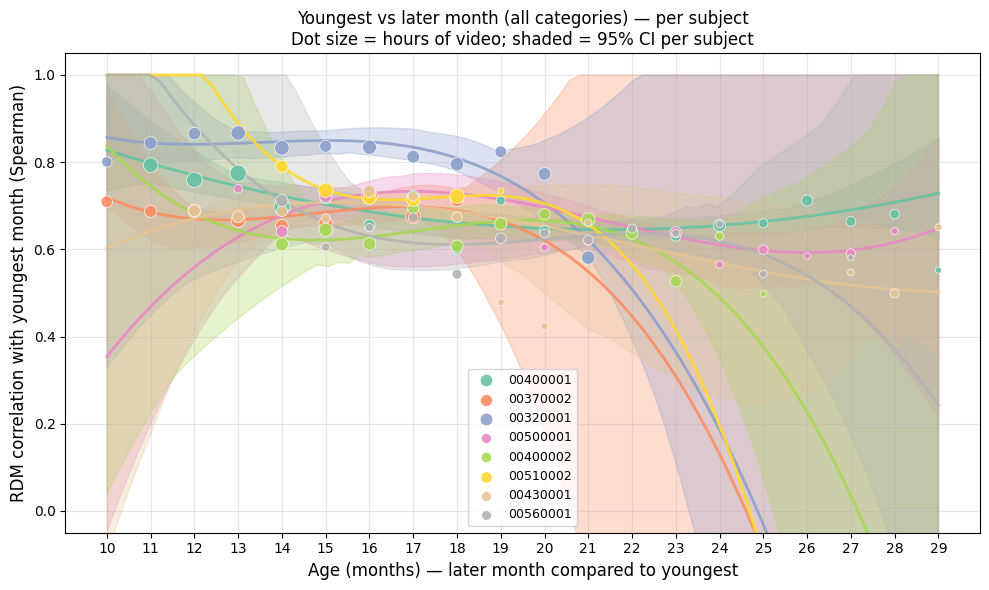

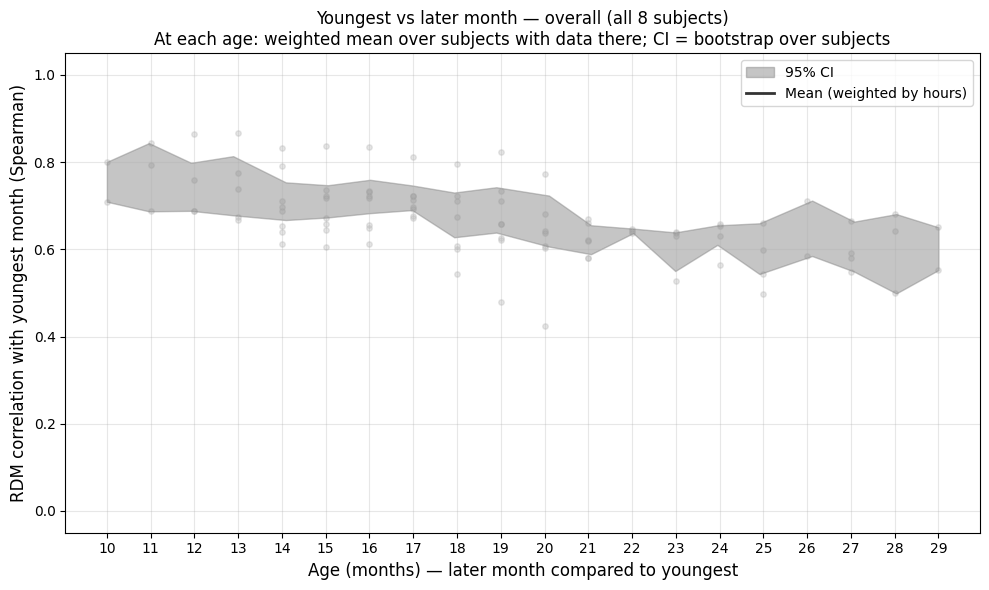

Saved youngest_vs_later_top8_densest_per_subject.* and youngest_vs_later_top8_densest_overall.*


In [12]:
# Plot 1: Per-subject only — each subject's smooth + 95% CI band + raw points (no overall on this plot)
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
# Per-subject 95% CI bands (draw first so behind)
for idx, subject_id in enumerate(top8_subject_ids):
    sv = smooth_yv[smooth_yv["subject_id"] == subject_id].sort_values("age")
    if len(sv) == 0:
        continue
    valid = sv["pred"].notna()
    if valid.any():
        c = colors[idx % len(colors)]
        ax.fill_between(sv.loc[valid, "age"], sv.loc[valid, "ci_lo"], sv.loc[valid, "ci_hi"], color=c, alpha=0.3, zorder=1)
# Per-subject smooth line + scatter
h_max = trajectory_youngest_df["hours_compared"].max() or 1
for idx, subject_id in enumerate(top8_subject_ids):
    sv = smooth_yv[smooth_yv["subject_id"] == subject_id].sort_values("age")
    sub = trajectory_youngest_df[trajectory_youngest_df["subject_id"] == subject_id].sort_values("age_compared")
    if len(sub) == 0:
        continue
    c = colors[idx % len(colors)]
    if len(sv) > 0 and sv["pred"].notna().any():
        ax.plot(sv["age"], sv["pred"], "-", color=c, linewidth=2, alpha=0.9, zorder=2)
    s = 20 + 120 * (sub["hours_compared"].fillna(0) / h_max)
    ax.scatter(sub["age_compared"], sub["correlation"], s=s, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5, label=subject_id)
age_min = int(trajectory_youngest_df["age_compared"].min())
age_max = int(trajectory_youngest_df["age_compared"].max())
ax.set_xticks(np.arange(age_min, age_max + 1))
ax.set_xlabel("Age (months) — later month compared to youngest", fontsize=12)
ax.set_ylabel("RDM correlation with youngest month (Spearman)", fontsize=12)
ax.set_title("Youngest vs later month (all categories) — per subject\nDot size = hours of video; shaded = 95% CI per subject")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_per_subject.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_per_subject.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 2: Overall only — aggregate across all 8 subjects (weighted mean at each age; 95% CI from bootstrap over subjects)
fig, ax = plt.subplots(figsize=(10, 6))
agg = aggregate_yv
valid = agg["pred"].notna()
if valid.any():
    ax.fill_between(agg.loc[valid, "age"], agg.loc[valid, "ci_lo"], agg.loc[valid, "ci_hi"], color="0.5", alpha=0.45, zorder=1, label="95% CI")
    ax.plot(agg["age"], agg["pred"], "k-", linewidth=2, alpha=0.8, label="Mean (weighted by hours)", zorder=2)
# Optional: show all points in background (light gray) to see the cloud
for idx, subject_id in enumerate(top8_subject_ids):
    sub = trajectory_youngest_df[trajectory_youngest_df["subject_id"] == subject_id].sort_values("age_compared")
    if len(sub) == 0:
        continue
    ax.scatter(sub["age_compared"], sub["correlation"], s=15, color="0.75", alpha=0.4, zorder=0)
age_min = int(trajectory_youngest_df["age_compared"].min())
age_max = int(trajectory_youngest_df["age_compared"].max())
ax.set_xticks(np.arange(age_min, age_max + 1))
ax.set_xlabel("Age (months) — later month compared to youngest", fontsize=12)
ax.set_ylabel("RDM correlation with youngest month (Spearman)", fontsize=12)
ax.set_title("Youngest vs later month — overall (all 8 subjects)\nAt each age: weighted mean over subjects with data there; CI = bootstrap over subjects")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_overall.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_overall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved youngest_vs_later_top8_densest_per_subject.* and youngest_vs_later_top8_densest_overall.*")

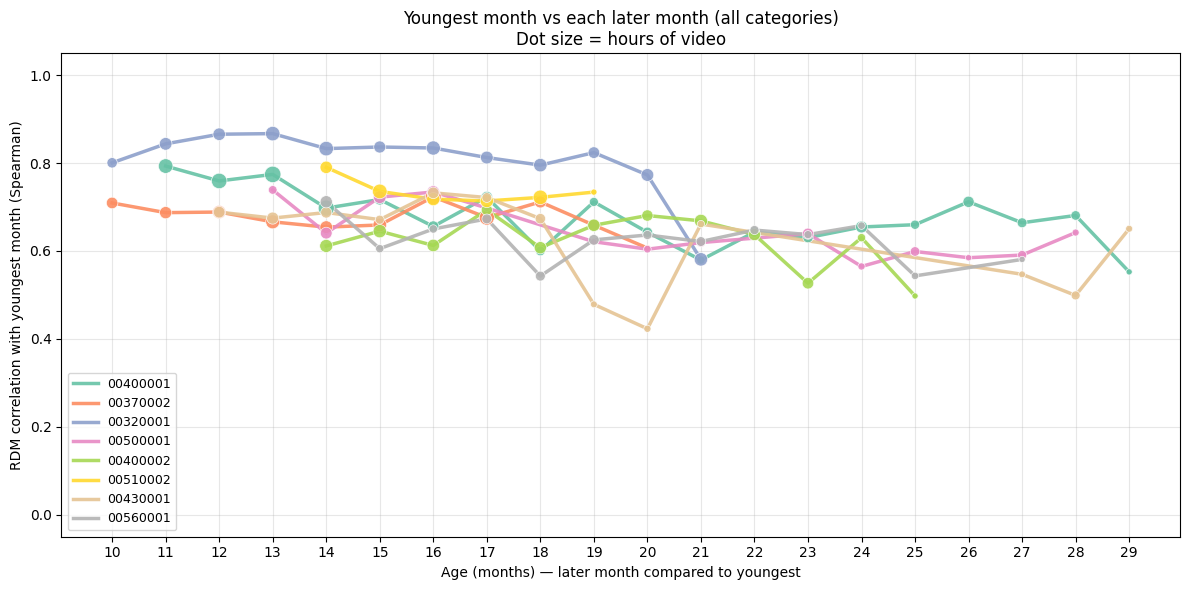

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/youngest_vs_later_top8_densest_categorical.pdf, .png


In [13]:
# Youngest vs later: categorical x (age_compared as integer ticks); fixed set per subject → fixed dot size
all_ages_compared = sorted(trajectory_youngest_df["age_compared"].unique())
age_to_xi = {a: i for i, a in enumerate(all_ages_compared)}
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
h_max = trajectory_youngest_df["hours_compared"].max() or 1
fig, ax = plt.subplots(figsize=(12, 6))
for idx, subject_id in enumerate(top8_subject_ids):
    sub = trajectory_youngest_df[trajectory_youngest_df["subject_id"] == subject_id].sort_values("age_compared")
    if len(sub) == 0:
        continue
    x_pos = [age_to_xi[a] for a in sub["age_compared"]]
    c = colors[idx % len(colors)]
    ax.plot(x_pos, sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    s = 20 + 120 * (sub["hours_compared"].fillna(0) / h_max)
    ax.scatter(x_pos, sub["correlation"], s=s, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
ax.set_xticks(range(len(all_ages_compared)))
ax.set_xticklabels([int(a) for a in all_ages_compared])
ax.set_xlabel("Age (months) — later month compared to youngest")
ax.set_ylabel("RDM correlation with youngest month (Spearman)")
ax.set_title("Youngest month vs each later month (all categories)\nDot size = hours of video")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_categorical.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_categorical.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'youngest_vs_later_top8_densest_categorical.pdf'}, .png")

### Plots: developmental trajectory — consecutive months (all categories)

Each subject: one line across consecutive age transitions (x = midpoint of from–to months, y = RDM correlation). Same fixed set of categories per subject; dot size is fixed.

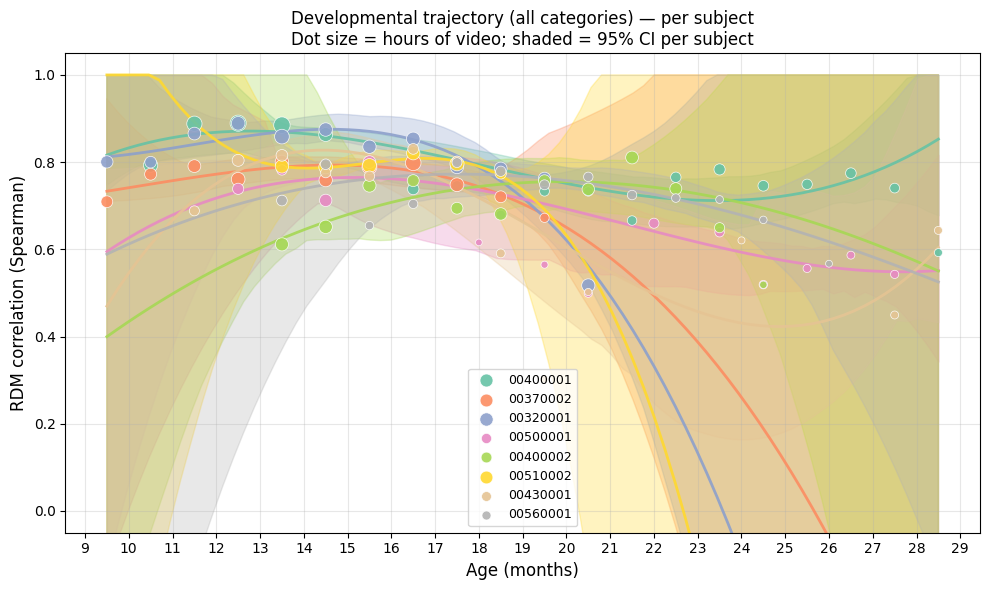

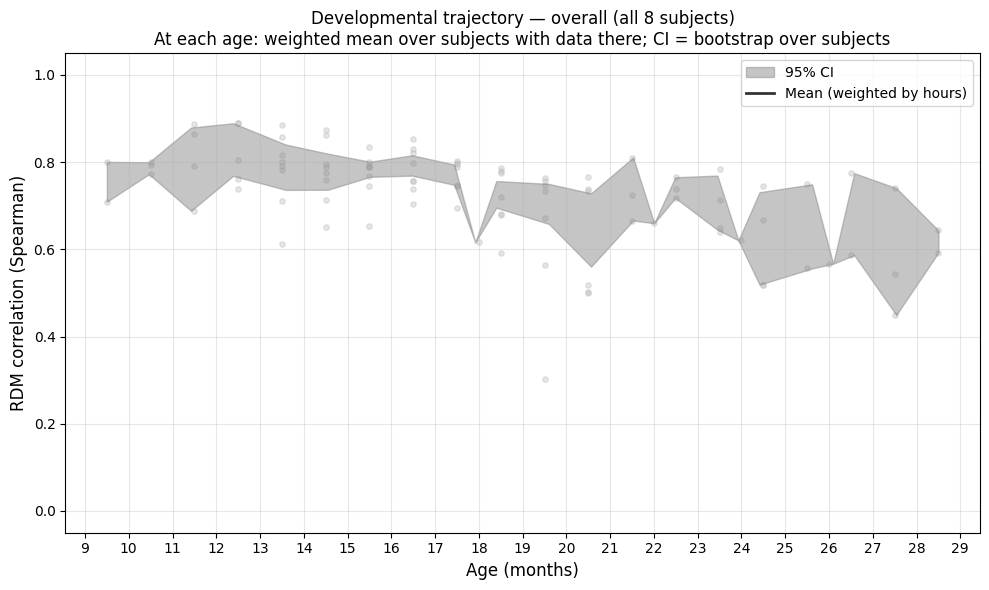

Saved correlation_trajectory_top8_densest_per_subject.* and correlation_trajectory_top8_densest_overall.*


In [14]:
# Developmental trajectory (month-to-month): Plot 1 = per subject only; Plot 2 = overall (aggregate by age)
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
# Per-subject 95% CI bands (draw first so behind)
for idx, subject_id in enumerate(top8_subject_ids):
    sv = smooth_mm[smooth_mm["subject_id"] == subject_id].sort_values("age")
    if len(sv) == 0:
        continue
    valid = sv["pred"].notna()
    if valid.any():
        c = colors[idx % len(colors)]
        ax.fill_between(sv.loc[valid, "age"], sv.loc[valid, "ci_lo"], sv.loc[valid, "ci_hi"], color=c, alpha=0.3, zorder=1)
h_max = trajectory_df["hours_bin"].max() or 1
for idx, subject_id in enumerate(top8_subject_ids):
    if subject_id not in trajectory_df["subject_id"].values:
        continue
    sv = smooth_mm[smooth_mm["subject_id"] == subject_id].sort_values("age")
    sub = trajectory_df[trajectory_df["subject_id"] == subject_id].sort_values("age_midpoint")
    c = colors[idx % len(colors)]
    if len(sv) > 0 and sv["pred"].notna().any():
        ax.plot(sv["age"], sv["pred"], "-", color=c, linewidth=2, alpha=0.9, zorder=2)
    s = 20 + 120 * (sub["hours_bin"].fillna(0) / h_max)
    ax.scatter(sub["age_midpoint"], sub["correlation"], s=s, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5, label=subject_id)
age_min = int(trajectory_df["age_from"].min())
age_max = int(trajectory_df["age_to"].max())
ax.set_xticks(np.arange(age_min, age_max + 1))
ax.set_xlabel("Age (months)", fontsize=12)
ax.set_ylabel("RDM correlation (Spearman)", fontsize=12)
ax.set_title("Developmental trajectory (all categories) — per subject\nDot size = hours of video; shaded = 95% CI per subject")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_per_subject.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_per_subject.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 2: Overall only — aggregate across all 8 subjects (weighted mean at each age)
fig, ax = plt.subplots(figsize=(10, 6))
agg = aggregate_mm
valid = agg["pred"].notna()
if valid.any():
    ax.fill_between(agg.loc[valid, "age"], agg.loc[valid, "ci_lo"], agg.loc[valid, "ci_hi"], color="0.5", alpha=0.45, zorder=1, label="95% CI")
    ax.plot(agg["age"], agg["pred"], "k-", linewidth=2, alpha=0.8, label="Mean (weighted by hours)", zorder=2)
for idx, subject_id in enumerate(top8_subject_ids):
    if subject_id not in trajectory_df["subject_id"].values:
        continue
    sub = trajectory_df[trajectory_df["subject_id"] == subject_id]
    ax.scatter(sub["age_midpoint"], sub["correlation"], s=15, color="0.75", alpha=0.4, zorder=0)
ax.set_xticks(np.arange(age_min, age_max + 1))
ax.set_xlabel("Age (months)", fontsize=12)
ax.set_ylabel("RDM correlation (Spearman)", fontsize=12)
ax.set_title("Developmental trajectory — overall (all 8 subjects)\nAt each age: weighted mean over subjects with data there; CI = bootstrap over subjects")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_overall.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_overall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved correlation_trajectory_top8_densest_per_subject.* and correlation_trajectory_top8_densest_overall.*")

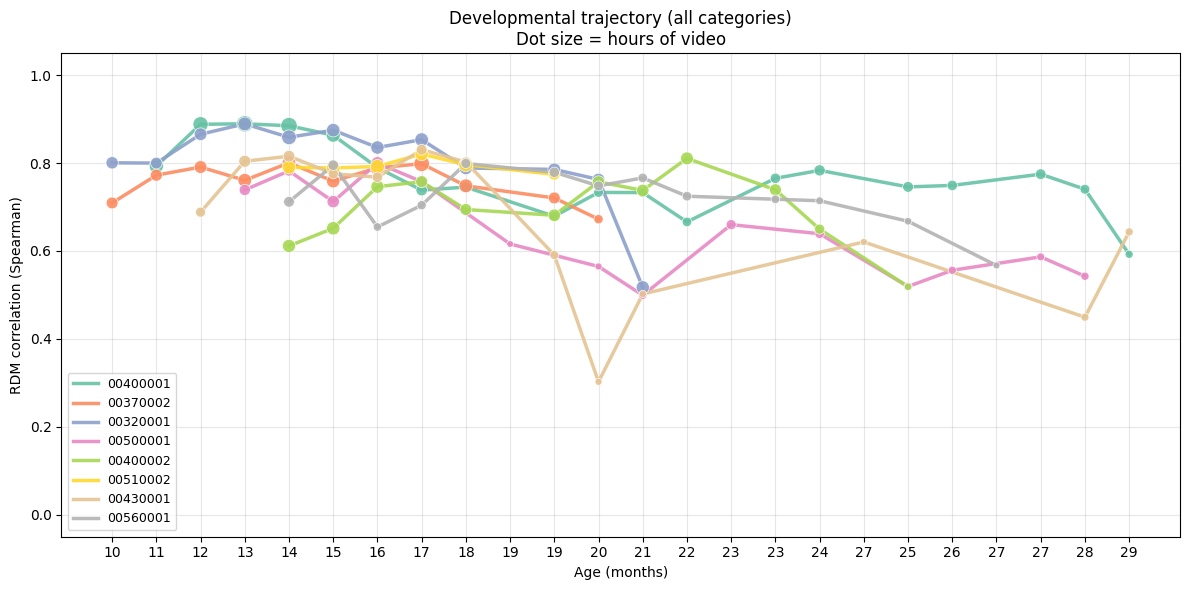

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/correlation_trajectory_top8_densest_categorical.pdf, .png


In [15]:
# Same with categorical x-axis; fixed set per subject → fixed dot size
all_midpoints = sorted(trajectory_df["age_midpoint"].unique())
midpoint_to_xi = {m: i for i, m in enumerate(all_midpoints)}
fig, ax = plt.subplots(figsize=(12, 6))
for idx, subject_id in enumerate(top8_subject_ids):
    if subject_id not in trajectory_df["subject_id"].values:
        continue
    sub = trajectory_df[trajectory_df["subject_id"] == subject_id].sort_values("age_midpoint")
    x_pos = [midpoint_to_xi[m] for m in sub["age_midpoint"]]
    c = colors[idx % len(colors)]
    ax.plot(x_pos, sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    s = 20 + 120 * (sub["hours_bin"].fillna(0) / (trajectory_df["hours_bin"].max() or 1))
    ax.scatter(x_pos, sub["correlation"], s=s, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
labels = [int(trajectory_df[trajectory_df["age_midpoint"] == m].iloc[0]["age_to"]) for m in all_midpoints]
ax.set_xticks(range(len(all_midpoints)))
ax.set_xticklabels(labels)
ax.set_xlabel("Age (months)")
ax.set_ylabel("RDM correlation (Spearman)")
ax.set_title("Developmental trajectory (all categories)\nDot size = hours of video")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_categorical.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_categorical.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'correlation_trajectory_top8_densest_categorical.pdf'}, .png")

### Combined: Developmental trajectory + individual RDMs (top 4 densest)

Left: developmental trajectory (dots scaled by hours, overall smooth + CI). Right: RDM heatmap for each of the top 4 densest subjects at their median age (fixed category set per subject).

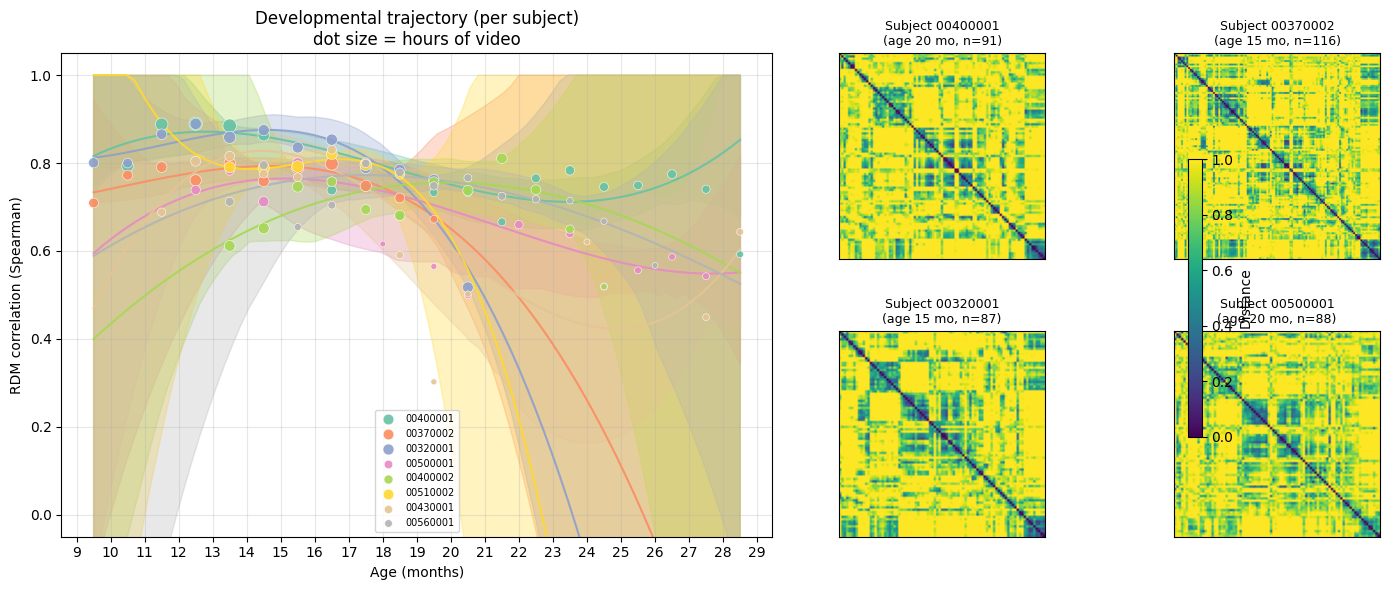

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/trajectory_plus_top4_rdms.pdf, .png


In [16]:
# Combined plot: trajectory (left) + top 4 densest individual RDMs (right)
top4 = top8_subject_ids[:N_TOP_DENSEST_FOR_RDM_PLOT]
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])
# Left: developmental trajectory (same as above, compact)
ax0 = fig.add_subplot(gs[0])
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
# Left: per-subject only (95% CI + smooth + scatter), no overall
for idx, subject_id in enumerate(top8_subject_ids):
    sv = smooth_mm[smooth_mm["subject_id"] == subject_id].sort_values("age")
    if len(sv) == 0:
        continue
    valid = sv["pred"].notna()
    if valid.any():
        c = colors[idx % len(colors)]
        ax0.fill_between(sv.loc[valid, "age"], sv.loc[valid, "ci_lo"], sv.loc[valid, "ci_hi"], color=c, alpha=0.3, zorder=1)
h_max = trajectory_df["hours_bin"].max() or 1
for idx, subject_id in enumerate(top8_subject_ids):
    if subject_id not in trajectory_df["subject_id"].values:
        continue
    sv = smooth_mm[smooth_mm["subject_id"] == subject_id].sort_values("age")
    sub = trajectory_df[trajectory_df["subject_id"] == subject_id].sort_values("age_midpoint")
    c = colors[idx % len(colors)]
    if len(sv) > 0 and sv["pred"].notna().any():
        ax0.plot(sv["age"], sv["pred"], "-", color=c, linewidth=1.5, alpha=0.9, zorder=2)
    s = 15 + 80 * (sub["hours_bin"].fillna(0) / h_max)
    ax0.scatter(sub["age_midpoint"], sub["correlation"], s=s, color=c, alpha=0.9, edgecolors="white", linewidths=0.4, zorder=5, label=subject_id)
ax0.set_xticks(np.arange(int(trajectory_df["age_from"].min()), int(trajectory_df["age_to"].max()) + 1))
ax0.set_xlabel("Age (months)")
ax0.set_ylabel("RDM correlation (Spearman)")
ax0.set_title("Developmental trajectory (per subject)\ndot size = hours of video")
ax0.legend(loc="best", fontsize=7)
ax0.grid(True, alpha=0.3)
ax0.set_ylim(-0.05, 1.05)
# Right: 2x2 RDM heatmaps for top 4 densest
gs_r = gs[1].subgridspec(2, 2, hspace=0.35, wspace=0.3)
rdm_axes = []
for i, subject_id in enumerate(top4):
    if subject_id not in subject_month_rdms or subject_fixed_categories.get(subject_id) is None:
        continue
    fixed_cats = subject_fixed_categories[subject_id]
    month_rdms = subject_month_rdms[subject_id]
    ages = sorted(month_rdms.keys())
    age_med = ages[len(ages) // 2]
    rdm, _ = month_rdms[age_med]
    common_idx = [ordered_categories.index(c) for c in fixed_cats]
    rdm_block = rdm[np.ix_(common_idx, common_idx)]
    ax = fig.add_subplot(gs_r[i // 2, i % 2])
    im = ax.imshow(rdm_block, cmap="viridis", aspect="equal", vmin=0, vmax=1)
    ax.set_title(f"Subject {subject_id}\n(age {age_med} mo, n={len(fixed_cats)})", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    rdm_axes.append(ax)
if rdm_axes:
    plt.colorbar(im, ax=rdm_axes, label="Distance", shrink=0.6)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "trajectory_plus_top4_rdms.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "trajectory_plus_top4_rdms.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'trajectory_plus_top4_rdms.pdf'}, .png")

## Top 50 categories only: same trajectory analysis

We repeat the same trajectory analyses using only the **first 50 categories from the long-tailed distribution** (by proportion detected, from `long_tailed_163cats/category_counts_163.csv`). This gives a fixed, comparable set across subjects and ages. For each subject and each age month we build the RDM using only those 50 categories (with at least `MIN_CATEGORIES_FOR_TOP50` present in that month). Consecutive-month and youngest-vs-later correlations use the common subset of the 50; dot size is fixed.

In [17]:
# Top 50 categories from long-tailed distribution (first 50 by Count in category_counts_163.csv)
counts_df = pd.read_csv(LONGTAIL_COUNTS_CSV)
ordered_categories_top50 = counts_df["Category"].head(N_TOP_CATEGORIES).tolist()
ordered_categories_top50 = [c for c in ordered_categories_top50 if c in set(ordered_categories)]
subject_month_rdms_top50 = {}
subject_trajectory_top50 = []

for subject_id in tqdm(subject_age_embeddings, desc="Subject (top50)"):
    age_data = subject_age_embeddings[subject_id]
    month_rdms = {}
    for age_mo, cat_embeddings in age_data.items():
        subset = {c: cat_embeddings[c] for c in ordered_categories_top50 if c in cat_embeddings}
        rdm, available = compute_rdm_for_month(
            subset, ordered_categories_top50, MIN_CATEGORIES_FOR_TOP50
        )
        if rdm is not None:
            month_rdms[age_mo] = (rdm, available)
    subject_month_rdms_top50[subject_id] = month_rdms
    ages_sorted = sorted(month_rdms.keys())
    for i in range(len(ages_sorted) - 1):
        a1, a2 = ages_sorted[i], ages_sorted[i + 1]
        rdm1, cats1 = month_rdms[a1]
        rdm2, cats2 = month_rdms[a2]
        corr, n_common = compute_rdm_correlation(rdm1, rdm2, ordered_categories_top50, cats1, cats2)
        subject_trajectory_top50.append({
            "subject_id": subject_id,
            "age_from": a1,
            "age_to": a2,
            "age_midpoint": (a1 + a2) / 2.0,
            "correlation": corr,
            "n_common_categories": n_common,
        })

trajectory_df_top50 = pd.DataFrame(subject_trajectory_top50)
trajectory_df_top50.to_csv(OUTPUT_DIR / "month_to_month_correlations_top50.csv", index=False)
print(f"Top-50 consecutive-month correlations: {len(trajectory_df_top50)} rows")
print(trajectory_df_top50.head(10).to_string())

Subject (top50): 100%|██████████| 8/8 [00:00<00:00, 52.42it/s]

Top-50 consecutive-month correlations: 100 rows
  subject_id  age_from  age_to  age_midpoint  correlation  n_common_categories
0   00400001        10      11          10.5     0.860007                   50
1   00400001        11      12          11.5     0.880763                   50
2   00400001        12      13          12.5     0.914423                   50
3   00400001        13      14          13.5     0.907323                   50
4   00400001        14      15          14.5     0.880490                   50
5   00400001        15      16          15.5     0.874044                   50
6   00400001        16      17          16.5     0.775317                   50
7   00400001        17      18          17.5     0.788448                   50
8   00400001        18      19          18.5     0.739336                   50
9   00400001        19      20          19.5     0.751929                   50


## Youngest month vs each later month (top 50 categories only)

Same as above but using only the first 50 categories. For each subject, correlate the youngest month's RDM with each later month's RDM (top-50 subset). Fixed set of 50 categories → fixed dot size.

In [18]:
# Youngest vs each later month, top 50 categories only
subject_trajectory_youngest_top50 = []
for subject_id in subject_month_rdms_top50:
    month_rdms = subject_month_rdms_top50[subject_id]
    if len(month_rdms) < 2:
        continue
    ages_sorted = sorted(month_rdms.keys())
    age_youngest = ages_sorted[0]
    rdm_youngest, cats_youngest = month_rdms[age_youngest]
    for age_other in ages_sorted[1:]:
        rdm_other, cats_other = month_rdms[age_other]
        corr, n_common = compute_rdm_correlation(
            rdm_youngest, rdm_other, ordered_categories_top50, cats_youngest, cats_other
        )
        subject_trajectory_youngest_top50.append({
            "subject_id": subject_id,
            "age_youngest": age_youngest,
            "age_compared": age_other,
            "correlation": corr,
            "n_common_categories": n_common,
        })

trajectory_youngest_df_top50 = pd.DataFrame(subject_trajectory_youngest_top50)
trajectory_youngest_df_top50.to_csv(OUTPUT_DIR / "youngest_vs_later_month_correlations_top50.csv", index=False)
print(f"Youngest vs later (top 50): {len(trajectory_youngest_df_top50)} rows")
print(trajectory_youngest_df_top50.head(12).to_string())

Youngest vs later (top 50): 100 rows
   subject_id  age_youngest  age_compared  correlation  n_common_categories
0    00400001            10            11     0.860007                   50
1    00400001            10            12     0.805743                   50
2    00400001            10            13     0.833326                   50
3    00400001            10            14     0.797761                   50
4    00400001            10            15     0.785874                   50
5    00400001            10            16     0.794428                   50
6    00400001            10            17     0.762590                   50
7    00400001            10            18     0.612264                   50
8    00400001            10            19     0.780890                   50
9    00400001            10            20     0.740914                   50
10   00400001            10            21     0.717873                   50
11   00400001            10            22     0.674

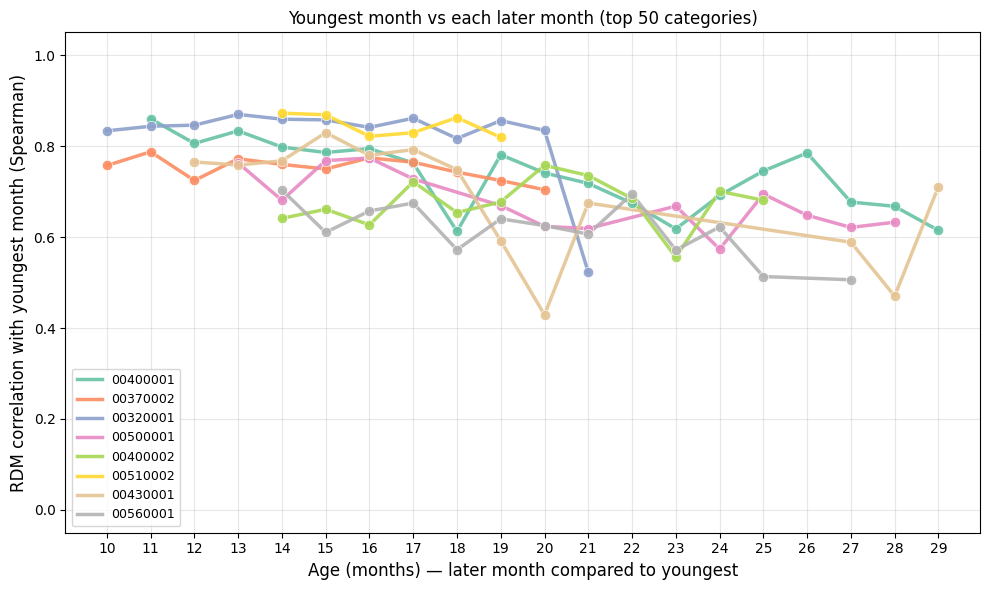

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/youngest_vs_later_top8_densest_top50.pdf, .png


In [19]:
# Plot: youngest vs later (top 50), continuous x. Fixed dot size (same 50 categories across age).
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
for idx, subject_id in enumerate(top8_subject_ids):
    sub = trajectory_youngest_df_top50[trajectory_youngest_df_top50["subject_id"] == subject_id].sort_values("age_compared")
    if len(sub) == 0:
        continue
    c = colors[idx % len(colors)]
    ax.plot(sub["age_compared"], sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    ax.scatter(sub["age_compared"], sub["correlation"], s=55, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
age_min = int(trajectory_youngest_df_top50["age_compared"].min())
age_max = int(trajectory_youngest_df_top50["age_compared"].max())
ax.set_xticks(np.arange(age_min, age_max + 1))
ax.set_xlabel("Age (months) — later month compared to youngest", fontsize=12)
ax.set_ylabel("RDM correlation with youngest month (Spearman)", fontsize=12)
ax.set_title("Youngest month vs each later month (top 50 categories)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_top50.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_top50.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'youngest_vs_later_top8_densest_top50.pdf'}, .png")

### Export data for R (top 50 categories)

Save top-50 trajectory tables with `n_rdm_pairs` and `cor_se` for use in R.

In [20]:
# Top 50: add n_rdm_pairs and cor_se, then save for R
trajectory_df_top50_export = add_rdm_se_columns(trajectory_df_top50)
trajectory_youngest_df_top50_export = add_rdm_se_columns(trajectory_youngest_df_top50)
trajectory_df_top50_export.to_csv(OUTPUT_DIR / "month_to_month_correlations_top50.csv", index=False)
trajectory_youngest_df_top50_export.to_csv(OUTPUT_DIR / "youngest_vs_later_month_correlations_top50.csv", index=False)
print("Exported top-50 data for R:")
print("  month_to_month_correlations_top50.csv")
print("  youngest_vs_later_month_correlations_top50.csv")

Exported top-50 data for R:
  month_to_month_correlations_top50.csv
  youngest_vs_later_month_correlations_top50.csv


In [21]:
# Models for top-50 data: run in R using the exported CSVs above.

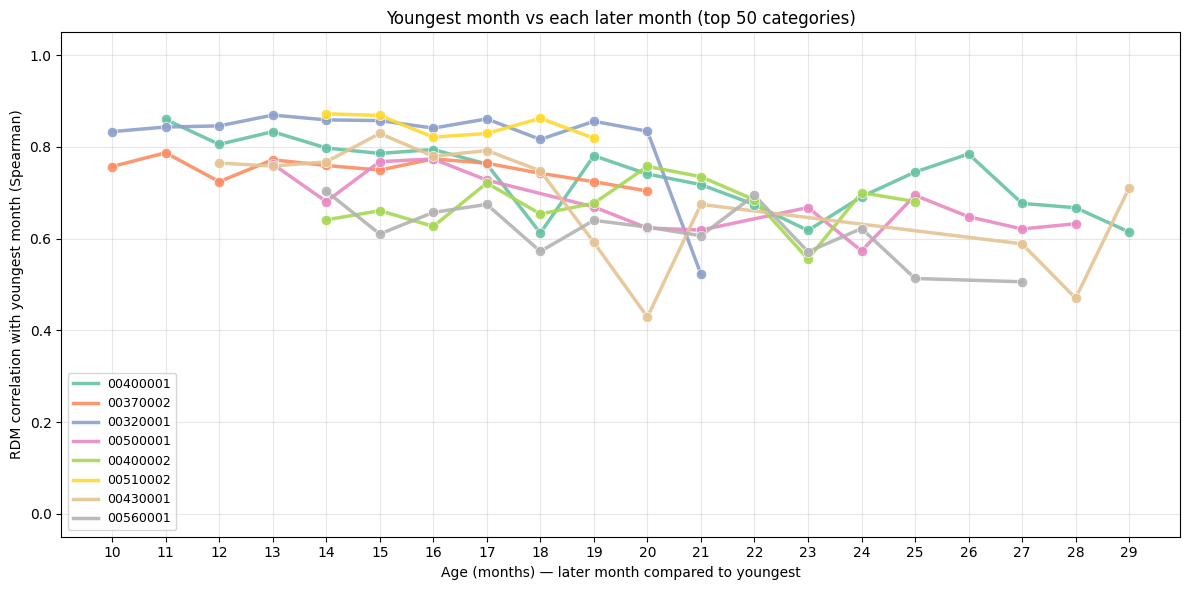

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/youngest_vs_later_top8_densest_top50_categorical.pdf, .png


In [22]:
# Youngest vs later (top 50): categorical x. Fixed dot size (same 50 categories).
all_ages_compared_t50 = sorted(trajectory_youngest_df_top50["age_compared"].unique())
age_to_xi_t50 = {a: i for i, a in enumerate(all_ages_compared_t50)}
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
fig, ax = plt.subplots(figsize=(12, 6))
for idx, subject_id in enumerate(top8_subject_ids):
    sub = trajectory_youngest_df_top50[trajectory_youngest_df_top50["subject_id"] == subject_id].sort_values("age_compared")
    if len(sub) == 0:
        continue
    x_pos = [age_to_xi_t50[a] for a in sub["age_compared"]]
    c = colors[idx % len(colors)]
    ax.plot(x_pos, sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    ax.scatter(x_pos, sub["correlation"], s=55, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
ax.set_xticks(range(len(all_ages_compared_t50)))
ax.set_xticklabels([int(a) for a in all_ages_compared_t50])
ax.set_xlabel("Age (months) — later month compared to youngest")
ax.set_ylabel("RDM correlation with youngest month (Spearman)")
ax.set_title("Youngest month vs each later month (top 50 categories)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_top50_categorical.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "youngest_vs_later_top8_densest_top50_categorical.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'youngest_vs_later_top8_densest_top50_categorical.pdf'}, .png")

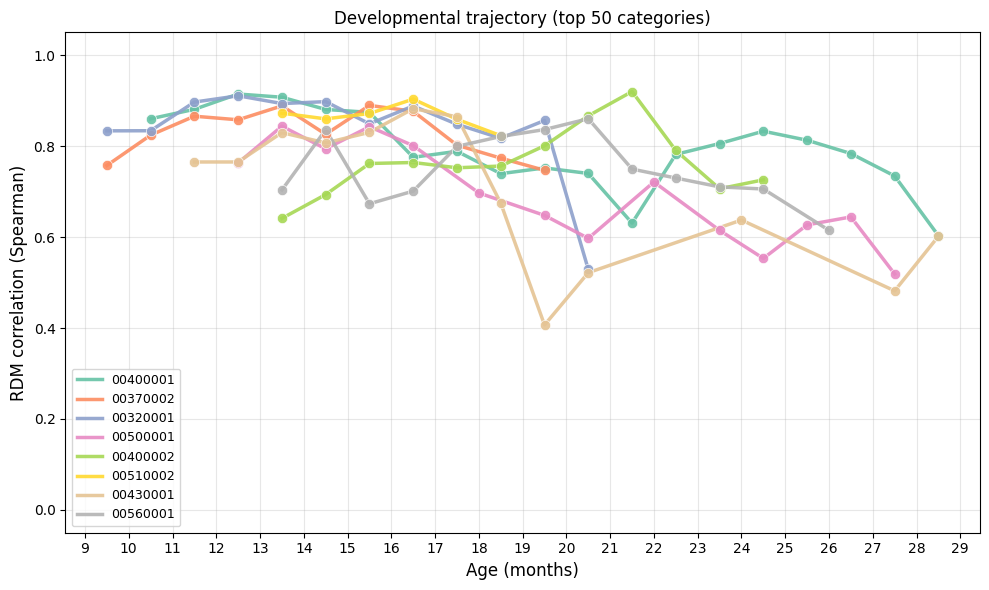

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/correlation_trajectory_top8_densest_top50.pdf, .png


In [23]:
# Top 50: continuous x-axis. Fixed dot size (same 50 categories across age).
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
for idx, subject_id in enumerate(top8_subject_ids):
    if subject_id not in trajectory_df_top50["subject_id"].values:
        continue
    sub = trajectory_df_top50[trajectory_df_top50["subject_id"] == subject_id].sort_values("age_midpoint")
    c = colors[idx % len(colors)]
    ax.plot(sub["age_midpoint"], sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    ax.scatter(sub["age_midpoint"], sub["correlation"], s=55, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
age_min = int(trajectory_df_top50["age_from"].min())
age_max = int(trajectory_df_top50["age_to"].max())
ax.set_xticks(np.arange(age_min, age_max + 1))
ax.set_xlabel("Age (months)", fontsize=12)
ax.set_ylabel("RDM correlation (Spearman)", fontsize=12)
ax.set_title("Developmental trajectory (top 50 categories)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_top50.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_top50.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'correlation_trajectory_top8_densest_top50.pdf'}, .png")

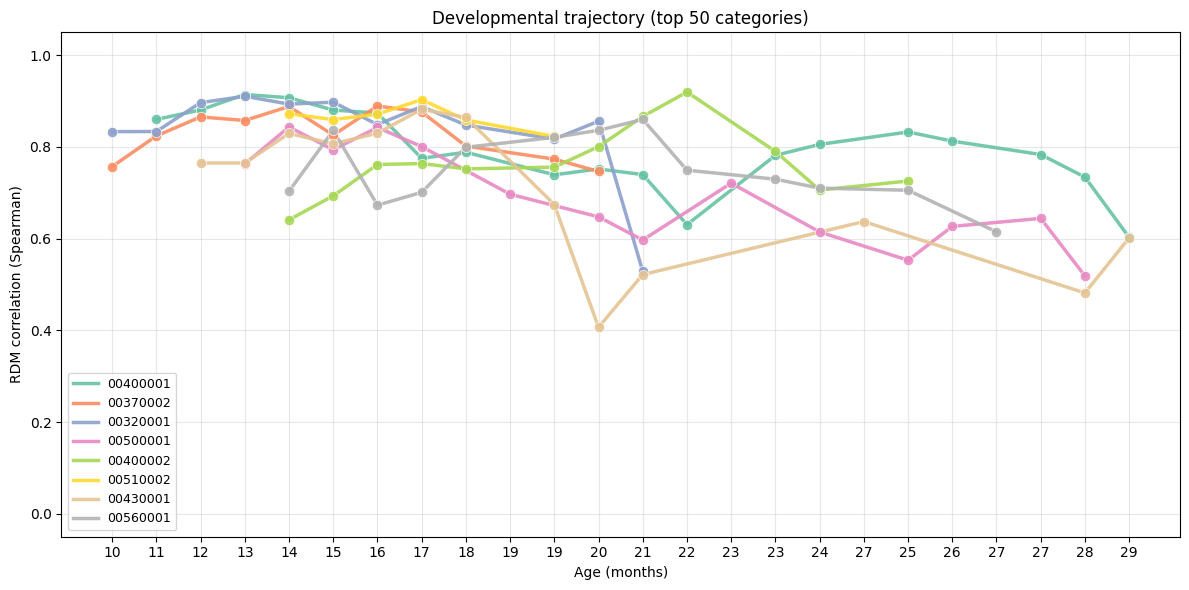

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/developmental_trajectory_top8_densest/correlation_trajectory_top8_densest_top50_categorical.pdf, .png


In [24]:
# Top 50: categorical x-axis. Fixed dot size (same 50 categories).
all_midpoints_t50 = sorted(trajectory_df_top50["age_midpoint"].unique())
midpoint_to_xi_t50 = {m: i for i, m in enumerate(all_midpoints_t50)}
colors = plt.cm.Set2(np.linspace(0, 1, max(8, len(top8_subject_ids))))
fig, ax = plt.subplots(figsize=(12, 6))
for idx, subject_id in enumerate(top8_subject_ids):
    if subject_id not in trajectory_df_top50["subject_id"].values:
        continue
    sub = trajectory_df_top50[trajectory_df_top50["subject_id"] == subject_id].sort_values("age_midpoint")
    x_pos = [midpoint_to_xi_t50[m] for m in sub["age_midpoint"]]
    c = colors[idx % len(colors)]
    ax.plot(x_pos, sub["correlation"], "-", color=c, linewidth=2.5, alpha=0.9, label=subject_id)
    ax.scatter(x_pos, sub["correlation"], s=55, color=c, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5)
labels_t50 = [int(trajectory_df_top50[trajectory_df_top50["age_midpoint"] == m].iloc[0]["age_to"]) for m in all_midpoints_t50]
ax.set_xticks(range(len(all_midpoints_t50)))
ax.set_xticklabels(labels_t50)
ax.set_xlabel("Age (months)")
ax.set_ylabel("RDM correlation (Spearman)")
ax.set_title("Developmental trajectory (top 50 categories)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_top50_categorical.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "correlation_trajectory_top8_densest_top50_categorical.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT_DIR / 'correlation_trajectory_top8_densest_top50_categorical.pdf'}, .png")